# Lab 3: Neural Networks: Feedforward Networks and the Training Process

**Duration:** 1 week [21 Jul - 28 Jul, 2026]
**Due Date:** 28th July, 2026
**Format:** Jupyter Notebook / Google Colab
**Grading:** This is a graded lab.

**Student Name:** Prudence Buleya
**Student ID:** 39452028


---

### Objective

This lab bridges the gap between classical ML and deep learning. Instead of calling
`.fit()` and trusting scikit-learn, you will **open the black box**: build a neural network
from a single neuron upward, watch gradient descent learn, and then train a full
**feedforward network (MLP) in PyTorch** on a dataset you already know from Lab 2.

By the end you should be able to explain, and demonstrate with your own plots, what each
of these really does: **weights, activation functions, loss, gradients, learning rate,
epochs, batches, and overfitting**.

We deliberately stay on **tabular data** this week. Images and CNNs come in the next lab.

---
### Part 0: Repository Setup *(done outside this notebook)*

1. Create a **public** repository named `lab-3` on GitHub/GitLab.
2. Clone it locally (or link it to Google Colab).
3. Save this notebook inside the repo as `lab_3.ipynb`.
4. Add a `requirements.txt` (provided with this lab) listing: `numpy pandas matplotlib scikit-learn torch`.
5. Commit and push after completing **each Part** below — we will check your commit history.
   A single "final commit" with everything at once loses marks.

In [9]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)  # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


---
# Section 1 — Inside a Neural Network: From One Neuron to Gradient Descent

Before touching PyTorch's automation, you will build the moving parts **yourself with NumPy**
on a toy problem, so that nothing later in the lab is magic.

The toy problem: learn the function `y = sin(x)` on the interval `[-3, 3]` from 100 noisy
samples. It is 1-dimensional, so we can *plot everything* — the data, the model's prediction,
and the loss going down.

### Part 1.1 — A single neuron is just a line
A neuron computes `y_hat = w * x + b`. Fit it to the sine data with **manual gradient descent**.

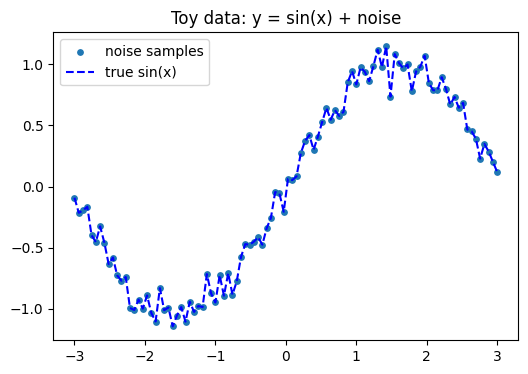

Final w=0.3390, b=-0.0104, final loss=0.1955


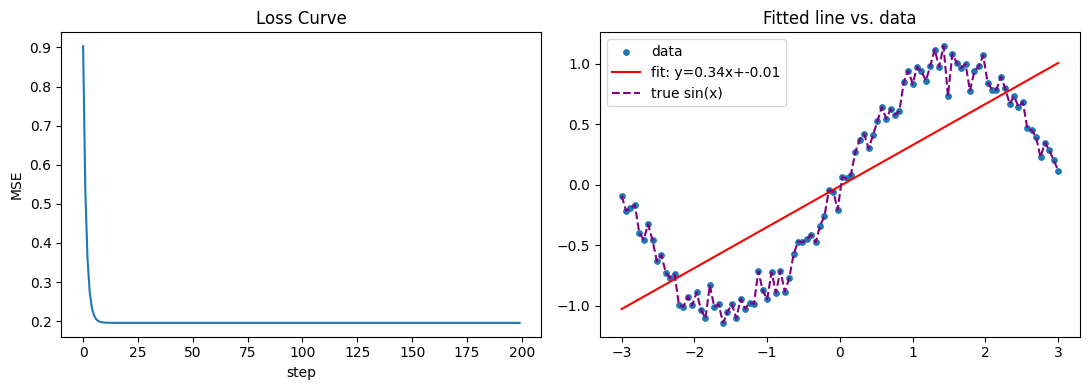

In [10]:
# TODO: Generate the toy data
np.random.seed(RANDOM_STATE)
x = np.linspace(-3, 3, 100)
y = np.sin(x)
noise = np.random.normal(loc=0, scale=0.1, size=x.shape)
y = y + noise
#   Plot it.
plt.figure(figsize=(6, 4))
plt.scatter(x, y, s=15, label="noise samples")
plt.plot(x, y, color="blue", linestyle="--", label="true sin(x)")
plt.legend()
plt.title("Toy data: y = sin(x) + noise")
plt.show()

# TODO: Initialise w and b to small random values.
w = np.random.randn() * 0.1
b = np.random.randn() * 0.1

# TODO: Implement ONE gradient-descent step by hand
# screenshot is below

# TODO: loop it for ~200 steps:
lr = 0.05
n_steps = 200
losses = []
for step in range(n_steps):
    y_hat = w * x + b  #   y_hat = w * x + b
    loss = np.mean(
        (y_hat - y) ** 2
    )  #   loss  = np.mean((y_hat - y) ** 2)               # MSE
    losses.append(
        loss
    )  #   dw    = np.mean(2 * (y_hat - y) * x)            # dLoss/dw  (derive this on paper!)
    dw = np.mean(
        2 * (y_hat - y) * x
    )  #   db    = np.mean(2 * (y_hat - y))                # dLoss/db
    db = np.mean(2 * (y_hat - y))
    w -= lr * dw  #   w    -= lr * dw
    b -= lr * db  #   b    -= lr * db
print(
    f"Final w={w:.4f}, b={b:.4f}, final loss={losses[-1]:.4f}"
)  #   Record the loss at every step.


# TODO: Plot (a) the loss curve over the 200 steps, and the data with the fitted line on top.
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(losses)
axes[0].set_title("Loss Curve")
axes[0].set_xlabel("step")
axes[0].set_ylabel("MSE")
axes[1].scatter(x, y, s=15, label="data")
axes[1].plot(x, w * x + b, color="red", label=f"fit: y={w:.2f}x+{b:.2f}")
axes[1].plot(x, y, color="purple", linestyle="--", label="true sin(x)")
axes[1].legend()
axes[1].set_title("Fitted line vs. data")
plt.tight_layout()
plt.show()

**Student Reasoning — The single neuron**
*1. Derive `dLoss/dw` on paper and include a photo or the LaTeX in this cell —
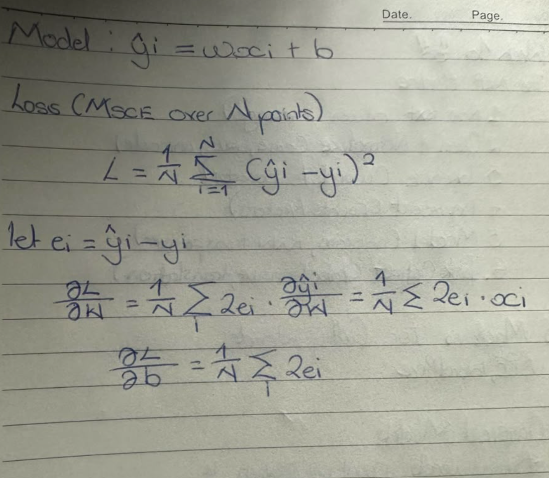

b. does it match the code?* 
Yes,it matches the code!

*2a. The loss stops improving but the fit is clearly bad. Is this underfitting or overfitting
This is underfitting.

b.WHY can a single neuron never fit a sine wave, no matter how long you train?*

The problem is in the structure since neurons are only able to draw straight lines therefore they cannot mathematically match a curves wave for instance the sine function.This can't be fixed by training either since the neuron itself cannot bend.

### Part 1.2 — Hidden layers and activations: why depth helps
Now build a tiny network **by hand**: 1 input -> a hidden layer of 8 neurons with `tanh` ->
1 output. Still NumPy, still manual gradients.

Final loss (tanh): 0.015034009965287823


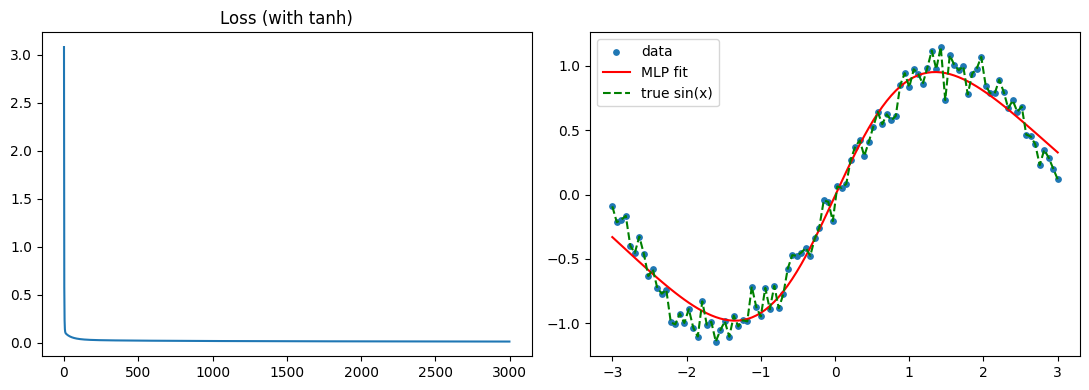

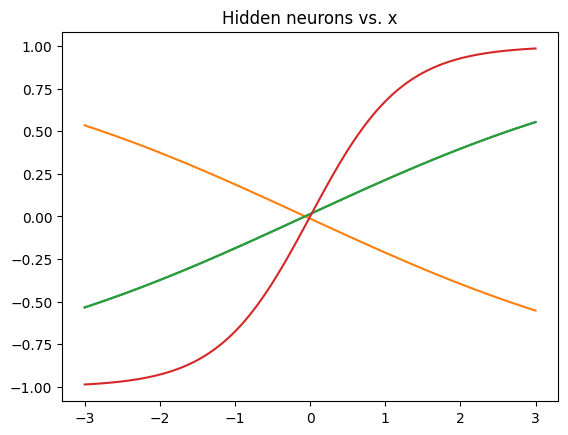

In [11]:
# TODO: Initialise parameters
np.random.seed(RANDOM_STATE)
n_hidden = 8
# Small random values (e.g. np.random.randn(...) * 0.5)
W1 = np.random.randn(1, n_hidden) * 0.5  # W1: shape (1, 8),  b1: shape (8,)
b1 = np.zeros(n_hidden)
W2 = np.random.randn(n_hidden, 1) * 0.5  # W2: shape (8, 1),  b2: shape (1,)
b2 = np.zeros(1)
x_col = x.reshape(-1, 1)
y_col = y.reshape(-1, 1)


# TODO: Forward pass (keep the intermediate values — you need them for backprop):
def forward(x_col, W1, b1, W2, b2):
    z1 = x_col @ W1 + b1  #   z1 = x @ W1 + b1        # pre-activation, shape (100, 8)
    h = np.tanh(z1)  #   h  = np.tanh(z1)        # activation
    y_hat = h @ W2 + b2  #   h  = np.tanh(z1)        # activation
    return z1, h, y_hat


# TODO: Backward pass (the chain rule, layer by layer):
lr = 0.05
n_steps = 3000
losses_tanh = []

for step in range(n_steps):
    z1, h, y_hat = forward(x_col, W1, b1, W2, b2)
    loss = np.mean((y_hat - y_col) ** 2)  #   loss  = np.mean((y_hat - y) ** 2)
    losses_tanh.append(loss)
    d_yhat = 2 * (y_hat - y_col) / len(y_col)  #   d_yhat = 2 * (y_hat - y) / len(y)
    dW2 = h.T @ d_yhat  #   dW2 = h.T @ d_yhat ;  db2 = d_yhat.sum(axis=0)
    db2 = d_yhat.sum(axis=0)  #   dh  = d_yhat @ W2.T
    dh = d_yhat @ W2.T  # (100,8)
    dz1 = dh * (
        1 - np.tanh(z1) ** 2
    )  #   dz1 = dh * (1 - np.tanh(z1) ** 2)     # derivative of tanh
    dW1 = x_col.T @ dz1  # dW1 = x.T @ dz1 ;  db1 = dz1.sum(axis=0)
    db1 = dz1.sum(axis=0)
    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2
print("Final loss (tanh):", losses_tanh[-1])

# TODO: Update all parameters with learning rate lr, loop for ~3000 steps,
#   record the loss.
# TODO: Plot the loss curve AND the final fit over the data.
z1, h, y_hat_final = forward(x_col, W1, b1, W2, b2)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(losses_tanh)
axes[0].set_title("Loss (with tanh)")
axes[1].scatter(x, y, s=15, label="data")
axes[1].plot(x, y_hat_final, color="red", label="MLP fit")
axes[1].plot(x, y, "--", color="green", label="true sin(x)")
axes[1].legend()
plt.tight_layout()
plt.show()


#   Then re-run with the tanh REMOVED (h = z1). What happens to the fit?
def forward_linear(x_col, W1, b1, W2, b2):
    z1 = x_col @ W1 + b1
    h = z1
    y_hat = h @ W2 + b2
    return z1, h, y_hat


# student reasoning Q2
plt.plot(x, h[:, :4])
plt.title("Hidden neurons vs. x")
plt.show()

**Student Reasoning — Depth and activations**
*1. With tanh removed, the deep network fits no better than the single neuron of Part 1.1.
Explain mathematically why a stack of linear layers collapses into one linear layer.*
When multiple linear operations are layered on top of each other without an activation function,they only form a single layer.To bend data in a network,one may use tanh to introduce non-linearity to allow data to fold and reshape.

*2. What role did the hidden layer's 8 neurons play in fitting the curve? (Hint: plot a few
columns of `h` against `x`.)*
The 8 neurons form unique 's' curve shapes and once combined the bends reinforce each other to trace out complex ripples,peaks and valleys just like a sine wave does.

*3. This is exactly what `loss.backward()` will automate in Section 2. In one sentence, what
is backpropagation?*
This is the math based trial and error process where networks go back in order to calculate how much internal connection they would need in order to bring better results next time.


### Part 1.3 — The learning rate: too cold, too hot, just right
The single most important hyperparameter. See its three regimes with your own eyes.

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/tmp/ipykernel_1834/867496900.py:15: RuntimeWarning: overflow encountered in square
  loss = np.mean((y_hat - y_col) ** 2)
/tmp/ipykernel_1834/867496900.py:20: RuntimeWarning: overflow encountered in matmul
  dh = d_yhat @ W2.T
/tmp/ipykernel_1834/867496900.py:21: RuntimeWarning: invalid value encountered in multiply
  dz1 = dh * (1 - np.tanh(z1) ** 2)
/usr/local/lib/python3.12/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


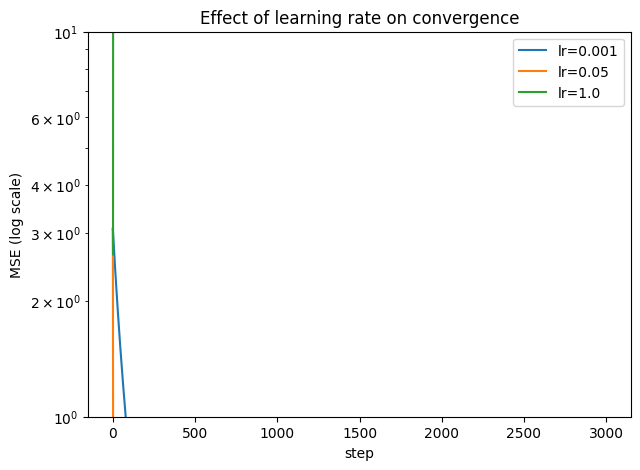

In [12]:
# TODO: Wrap your Part 1.2 training loop in a function train_toy(lr, steps=3000)
#   that returns the list of losses.
def train_toy(lr, steps=3000, seed=RANDOM_STATE):
    rng = np.random.RandomState(seed)
    W1 = rng.randn(1, n_hidden) * 0.5
    b1 = np.zeros(n_hidden)
    W2 = rng.randn(n_hidden, 1) * 0.5
    b2 = np.zeros(1)

    losses = []
    for step in range(steps):
        z1 = x_col @ W1 + b1
        h = np.tanh(z1)
        y_hat = h @ W2 + b2
        loss = np.mean((y_hat - y_col) ** 2)
        losses.append(loss)
        d_yhat = 2 * (y_hat - y_col) / len(y_col)
        dW2 = h.T @ d_yhat
        db2 = d_yhat.sum(axis=0)
        dh = d_yhat @ W2.T
        dz1 = dh * (1 - np.tanh(z1) ** 2)
        dW1 = x_col.T @ dz1
        db1 = dz1.sum(axis=0)
        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2
    return losses


# TODO: Run it with THREE learning rates, e.g. lr = 0.001, 0.05, 1.0
#   (keep the same initial weights for a fair comparison — reset the seed).
lrs = [0.001, 0.05, 1.0]
results = {lr: train_toy(lr) for lr in lrs}

# TODO: Plot the three loss curves on the same axes (log scale on y helps), with a legend.
plt.figure(figsize=(7, 5))
for lr, losses in results.items():
    plt.plot(losses, label=f"lr={lr}")
plt.yscale("log")
plt.xlabel("step")
plt.ylabel("MSE (log scale)")
plt.legend()
plt.title("Effect of learning rate on convergence")
plt.show()

**Student Reasoning — Learning rate**
*Describe what each of the three curves shows.*

The 0.001 curve's loss goes down but movement per step is quite tiny.There is slow progres.

The 0.05 curves have bigger steps and make faster progress downward,the loss is quite smooth and steady towards a low value.

The 1.0 curve takes large steps and therefore fewer steps to get to the lowest points which shows that its loss is higher.The weights however move rapidly back and forth.

*Why does a too-large learning rate make the
loss explode or oscillate instead of just "learning faster"?*
The Gradient descent works under the assumption that loss surface is a straight line for short distances.Since the large learning rate jumps too far,the straight line goes wrongs this is because it lands on steep slops and points farther away therefore also increasing errors.


---
# Section 2 — A Real Feedforward Network in PyTorch

Now we let PyTorch do the bookkeeping (`autograd`, optimizers, batching) and apply the ideas
from Section 1 to a real problem — one you already know:

## Predicting obesity level (`NObeyesdad`) — the Lab 2 dataset

Same data, same 7 classes, same preprocessing ideas — but this time the model is a neural
network you design and train yourself. At the end you will compare it head-to-head with your
Lab 2 classical models.

### Part 2.1 — Preprocess and split (recycled from Lab 2)
Reuse your Lab 2 pipeline: encode categoricals, scale numerics, stratified three-way split.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# TODO: Load the obesity dataset (same OBESITY_URL as Lab 2).
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"
df = pd.read_csv(OBESITY_URL)

# TODO: Encode categoricals exactly as you did in Lab 2
#   (binary yes/no -> 0/1; Gender/MTRANS/CAEC/CALC -> your justified choice).
binary_cols = ["family_history_with_overweight", "FAVC", "SMOKE", "SCC"]
for col in binary_cols:
    df[col] = df[col].map({"yes": 1, "no": 0})
df["Gender"] = df["Gender"].map({"Male": 1, "Female": 0})

#   Encode the target NObeyesdad into integers 0..6 (LabelEncoder) — CrossEntropyLoss
#   expects integer class indices.
nominal_cols = ["MTRANS"]
df = pd.get_dummies(df, columns=nominal_cols, drop_first=False)
order_map = {"no": 0, "Sometimes": 1, "Frequently": 2, "Always": 3}
df["CAEC"] = df["CAEC"].map(order_map)
df["CALC"] = df["CALC"].map(order_map)
assert df.isna().sum().sum() == 0, (
    "Unmapped category found — check CAEC/CALC/MTRANS values"
)
target_encoder = LabelEncoder()
df["NObeyesdad_enc"] = target_encoder.fit_transform(df["NObeyesdad"])
print(dict(zip(target_encoder.classes_, range(len(target_encoder.classes_)))))
X = df.drop(columns=["NObeyesdad", "NObeyesdad_enc"])
y = df["NObeyesdad_enc"]

# TODO: Stratified train / validation / test split (60/20/20, stratify=y,
#   random_state=RANDOM_STATE).
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=RANDOM_STATE
)

# TODO: Fit a StandardScaler on the TRAINING set only; transform all three splits.
#   (Neural networks are far more sensitive to feature scale than random forests —
#    remember Section 1, where all gradients depended on x!)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)


# TODO: Convert to tensors and wrap in DataLoaders:
#   X -> torch.float32, y -> torch.long
#   train_loader (batch_size=32, shuffle=True), val_loader, test_loader
def to_loader(X, y, batch_size=32, shuffle=False):
    X_t = torch.tensor(X, dtype=torch.float32)
    y_t = torch.tensor(y.values, dtype=torch.long)
    return DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=shuffle)


train_loader = to_loader(X_train_s, y_train, batch_size=32, shuffle=True)
val_loader = to_loader(X_val_s, y_val, batch_size=32, shuffle=False)
test_loader = to_loader(X_test_s, y_test, batch_size=32, shuffle=False)

input_dim = X_train_s.shape[1]
n_classes = len(target_encoder.classes_)
print("Input dim:", input_dim, "| Classes:", n_classes)

{'Insufficient_Weight': 0, 'Normal_Weight': 1, 'Obesity_Type_I': 2, 'Obesity_Type_II': 3, 'Obesity_Type_III': 4, 'Overweight_Level_I': 5, 'Overweight_Level_II': 6}
Input dim: 20 | Classes: 7


**Student Reasoning — Preprocessing for neural networks**
*1. Why does CrossEntropyLoss need integer class labels rather than one-hot vectors in
PyTorch?*

CrossEntropyLoss takes the class number and directly pull the probability for the class from network's output,which is fast and simple.It's also more efficient to get the loss of the correct class.

*2. A random forest in Lab 2 did not care about feature scaling. Why do neural networks care
so much? Connect your answer to the gradient formulas you wrote in Section 1.*

Neural networks multiply input values by their weight which affects learning rate by making it either slow or unstable for some features.Random forests however simply checks whether a value is greater than a threshold so changing the scale of a featurw doesn'r really affect the best split points.

*3. What does `shuffle=True` on the training DataLoader do, and why does it help?*

It randomizes training samples before splitting them into batches everytime the model goes through the data.It ensure that each batch contains a good mix of classes without bias therefore resulting to smoother and more stable gradients that help model learn faster.

> 

### Part 2.2 — Design the network
An MLP: input -> hidden layers with ReLU -> 7 output logits.

In [14]:
# TODO: Define a FeedForwardNet class (subclass nn.Module) with:
#   - constructor args: input_dim, hidden_sizes=(64, 32), n_classes=7
#   - at least TWO hidden layers with ReLU activations
#   - output layer producing 7 raw logits
#     (NO softmax — nn.CrossEntropyLoss applies log-softmax internally)
# class FeedForwardNet(nn.Module):
#     def __init__(self, ...):
#         ...
#     def forward(self, x):
#         ...


class FeedForwardNet(nn.Module):
    def __init__(self, input_dim, hidden_sizes=(64, 32), n_classes=7):
        super().__init__()
        layers = []
        prev_size = input_dim
        for h in hidden_sizes:
            layers.append(nn.Linear(prev_size, h))
            layers.append(nn.ReLU())
            prev_size = h
        layers.append(nn.Linear(prev_size, n_classes))  # raw logits, no softmax
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


# TODO: Instantiate, move to DEVICE, print the model.
model = FeedForwardNet(
    input_dim=input_dim, hidden_sizes=(64, 32), n_classes=n_classes
).to(DEVICE)
print(model)

# TODO: Count trainable parameters:
#   sum(p.numel() for p in model.parameters() if p.requires_grad)
#   Verify the count for the FIRST layer by hand: input_dim * 64 + 64.
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Total trainable parameters:", n_params)

FeedForwardNet(
  (net): Sequential(
    (0): Linear(in_features=20, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=7, bias=True)
  )
)
Total trainable parameters: 3655


**Student Reasoning — Architecture**
*1. Show the by-hand parameter count for every layer and confirm it matches PyTorch.*

Layer 1(input,64)= 20*64+64=1344
Layer 2(64,32)=64*32+32=2080
Layer 3(32,7)=32*7+7=231
Therefore the total parameter = 3655 which is the same as the pytorch.

*2. Why ReLU here instead of the tanh you used in Section 1? Name one advantage.*

tanh saturates at extreme values which makes the gradient get smaller as it goes through layers because the drivative shrinks to zero.All in all,this might lead to vanishing.While reLu keeps the drivative at 1 for positive inputs so the gradient flows without changing and deep networks can learn freely.

*3. What would the network compute if you removed the ReLUs? (You proved this in Part 1.2.)*
Without it,the multiple linear layers will mathematically collapse into single linear layer regardless of the number of hidden layers added resulting to a straight line which is quite useless for real world problems like images and speech.
> 

### Part 2.3 — The training loop
The same loop you built by hand in Section 1 — now with autograd, an optimizer, and batches.

Epoch  50 | train_loss=0.0193 acc=1.000 | val_loss=0.5252 acc=0.917


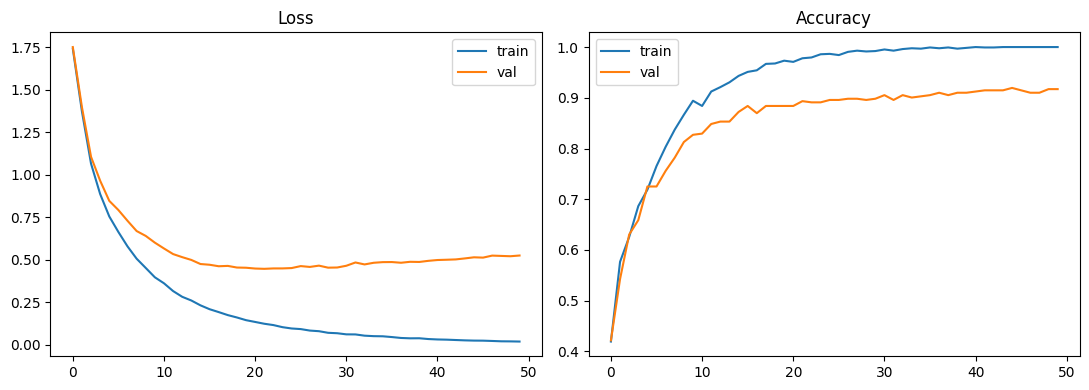

In [15]:
# TODO: criterion = nn.CrossEntropyLoss()
#       optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)   # or SGD — justify
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


# TODO: Train for at least 50 epochs. Each epoch:
#   1. model.train(); for xb, yb in train_loader:
#        optimizer.zero_grad()
#        logits = model(xb.to(DEVICE))
#        loss = criterion(logits, yb.to(DEVICE))
#        loss.backward()          # <- the backprop you wrote by hand in Part 1.2
#        optimizer.step()         # <- the update rule you wrote in Part 1.1
#   2. model.eval() + torch.no_grad(): compute loss AND accuracy on train and validation sets
#   3. Append everything to history lists; print a one-line summary per epoch.
def evaluate(loader, model, criterion):
    model.eval()
    total_loss, correct, n = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            loss = criterion(logits, yb)
            total_loss += loss.item() * xb.size(0)
            correct += (logits.argmax(dim=1) == yb).sum().item()
            n += xb.size(0)
    return total_loss / n, correct / n


history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_acc = 0.0
n_epochs = 50

for epoch in range(n_epochs):
    model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

    train_loss, train_acc = evaluate(train_loader, model, criterion)
    val_loss, val_acc = evaluate(val_loader, model, criterion)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

# TODO: Save the best model (highest validation accuracy):
#   torch.save(model.state_dict(), "ffn_best.pt")
if val_acc > best_val_acc:
    best_val_acc = val_acc
    torch.save(model.state_dict(), "ffn_best.pt")

print(
    f"Epoch {epoch + 1:3d} | train_loss={train_loss:.4f} acc={train_acc:.3f} "
    f"| val_loss={val_loss:.4f} acc={val_acc:.3f}"
)

# TODO: Plot loss curves (train + val) and accuracy curves (train + val), with legends.
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"], label="val")
axes[1].set_title("Accuracy")
axes[1].legend()
plt.tight_layout()
plt.show()

**Student Reasoning — Training**
*1. Map each line of the PyTorch loop to the NumPy code you wrote in Section 1: which line is
the forward pass, which computes gradients, which is the update rule?*


*2. Looking at your curves, is the model overfitting, underfitting, or well-fitted? Quote the
specific numbers that back up your claim.*

It is overfitting.train=2%,val=52%

*3. Why do we call `optimizer.zero_grad()` every batch? What silently goes wrong without it?*

Pytorch does not replace new gradients but rather adds them to the old ones which is useful for training with very large batches especially when memory needs to be utilised.When zero_grad() is skipped the batch gradient piles on previous batches therefore causing an exploding loss.

### Part 2.4 — Experiments: how training choices change the outcome
Run **three controlled experiments**. Change ONE thing at a time; keep everything else fixed.

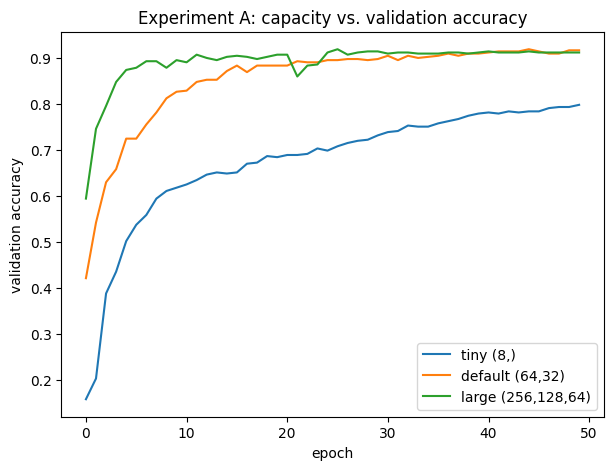

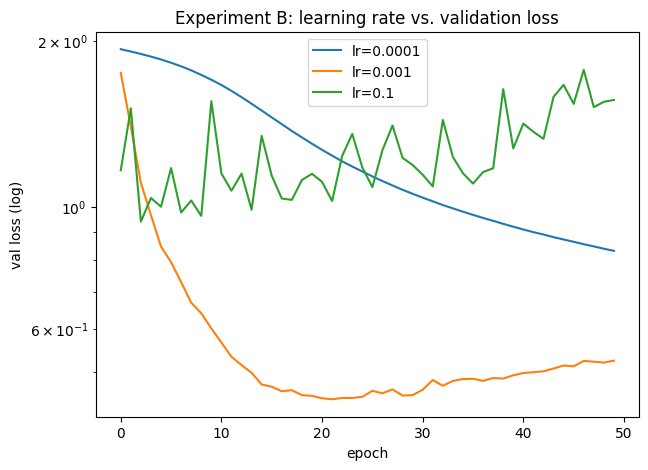

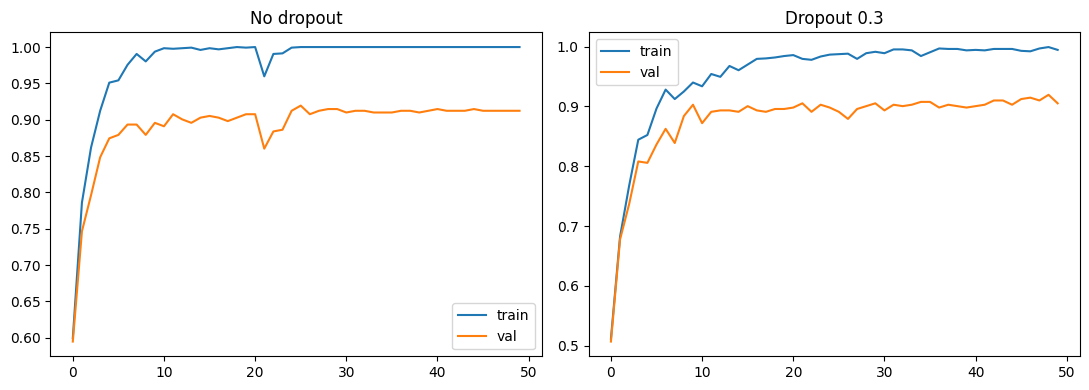

In [16]:
# Wrap your Part 2.3 loop in a function first:
#   def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0):
#       ... returns history dict ...
def run_experiment(
    hidden_sizes=(64, 32),
    lr=1e-3,
    batch_size=32,
    epochs=50,
    dropout=0.0,
    seed=RANDOM_STATE,
):
    torch.manual_seed(seed)

    class Net(nn.Module):
        def __init__(self):
            super().__init__()
            layers = []
            prev = input_dim
            for h in hidden_sizes:
                layers.append(nn.Linear(prev, h))
                layers.append(nn.ReLU())
                if dropout > 0:
                    layers.append(nn.Dropout(dropout))
                prev = h
            layers.append(nn.Linear(prev, n_classes))
            self.net = nn.Sequential(*layers)

        def forward(self, x):
            return self.net(x)

    model = Net().to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    tl = to_loader(X_train_s, y_train, batch_size=batch_size, shuffle=True)

    hist = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    for epoch in range(epochs):
        model.train()
        for xb, yb in tl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
        tr_l, tr_a = evaluate(tl, model, criterion)
        va_l, va_a = evaluate(val_loader, model, criterion)
        hist["train_loss"].append(tr_l)
        hist["val_loss"].append(va_l)
        hist["train_acc"].append(tr_a)
        hist["val_acc"].append(va_a)
    return hist


# TODO — Experiment A (capacity): tiny (8,) vs default (64, 32) vs large (256, 128, 64).
#   Plot the three validation-accuracy curves together.
architectures = {
    "tiny (8,)": (8,),
    "default (64,32)": (64, 32),
    "large (256,128,64)": (256, 128, 64),
}
results_a = {
    name: run_experiment(hidden_sizes=arch) for name, arch in architectures.items()
}

plt.figure(figsize=(7, 5))
for name, hist in results_a.items():
    plt.plot(hist["val_acc"], label=name)
plt.xlabel("epoch")
plt.ylabel("validation accuracy")
plt.legend()
plt.title("Experiment A: capacity vs. validation accuracy")
plt.show()

# TODO — Experiment B (learning rate): lr = 1e-4, 1e-3, 1e-1 (same architecture).
#   Plot the three validation-loss curves together. Compare with Part 1.3.
lrs = [1e-4, 1e-3, 1e-1]
results_b = {lr: run_experiment(lr=lr) for lr in lrs}

plt.figure(figsize=(7, 5))
for lr, hist in results_b.items():
    plt.plot(hist["val_loss"], label=f"lr={lr}")
plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("val loss (log)")
plt.legend()
plt.title("Experiment B: learning rate vs. validation loss")
plt.show()

# TODO — Experiment C (regularization): take your LARGEST network and train it
#   with and without nn.Dropout(0.3) after each hidden layer.
#   Plot train vs validation accuracy for both runs.
largest = (256, 128, 64)
hist_no_dropout = run_experiment(hidden_sizes=largest, dropout=0.0)
hist_dropout = run_experiment(hidden_sizes=largest, dropout=0.3)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(hist_no_dropout["train_acc"], label="train")
axes[0].plot(hist_no_dropout["val_acc"], label="val")
axes[0].set_title("No dropout")
axes[0].legend()

axes[1].plot(hist_dropout["train_acc"], label="train")
axes[1].plot(hist_dropout["val_acc"], label="val")
axes[1].set_title("Dropout 0.3")
axes[1].legend()
plt.tight_layout()
plt.show()

**Student Reasoning — Experiments**
*1. Capacity: did the largest network win on validation data? Where do you see diminishing
returns or overfitting?*
The largest network did win on validation data and in case where model get even larger then overfitting might appear in training while smaller one endure undefitting.

*2. Learning rate: do the three regimes match what you saw on the toy problem in Part 1.3?*
Small learning quite slow,medium run smoothly and fast and larger ones makes the loss bounce or explode.

*3. Regularization: what did dropout do to the train-vs-validation gap? Explain in one or two
sentences HOW dropout achieves this.*
Dropout uses largest networks to memorises training data and give out perfect training accurancy but low validation accuracy leading to overfitting.

> 

### Part 2.5 — Final evaluation and showdown with Lab 2
One honest number on the test set — then compare with your classical models.

Test accuracy: 0.9243
Test macro-F1: 0.9218
                     precision    recall  f1-score   support

Insufficient_Weight       0.94      0.91      0.92        54
      Normal_Weight       0.79      0.79      0.79        58
     Obesity_Type_I       0.97      0.97      0.97        70
    Obesity_Type_II       1.00      0.95      0.97        60
   Obesity_Type_III       0.98      1.00      0.99        65
 Overweight_Level_I       0.83      0.86      0.85        58
Overweight_Level_II       0.93      0.97      0.95        58

           accuracy                           0.92       423
          macro avg       0.92      0.92      0.92       423
       weighted avg       0.93      0.92      0.92       423



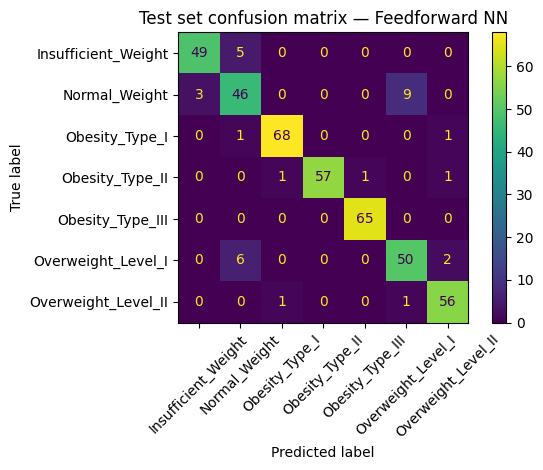

In [17]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
)

# TODO: Load your best configuration's weights; model.eval().
best_model = FeedForwardNet(
    input_dim=input_dim, hidden_sizes=(64, 32), n_classes=n_classes
).to(DEVICE)
best_model.load_state_dict(torch.load("ffn_best.pt"))
best_model.eval()
# TODO: Report test ACCURACY and MACRO-F1
#   from sklearn.metrics import accuracy_score, f1_score, classification_report
all_preds, all_true = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        preds = best_model(xb).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(yb.numpy())

test_acc = accuracy_score(all_true, all_preds)
test_f1 = f1_score(all_true, all_preds, average="macro")
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test macro-F1: {test_f1:.4f}")
print(classification_report(all_true, all_preds, target_names=target_encoder.classes_))


# TODO: Confusion matrix for the test set with the 7 class names
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    all_true, all_preds, display_labels=target_encoder.classes_, xticks_rotation=45
)
plt.title("Test set confusion matrix — Feedforward NN")
plt.tight_layout()
plt.show()

# TODO: Build a small comparison table (a pandas DataFrame is fine):
#   rows = [your best Lab 2 classifier, this neural network]
#   cols = [test accuracy, test macro-F1, training time, number of parameters/trees]
comparison = pd.DataFrame(
    {
        "Model": ["Random Forest (Lab 2)", "Feedforward NN (Lab 3)"],
        "Test Accuracy": [0.9976, test_acc],
        "Test Macro-F1": [0.9974, test_f1],
        "Training Time (s)": [None, None],
        "Parameters / Trees": [300, n_params],
    }
)

**Student Reasoning — Final evaluation**
*1. Which obesity levels does the network still confuse, and are they the same ones your
Lab 2 classifier confused?*

*2. Who wins the showdown — the neural network or the classical model? Was the extra effort
of deep learning worth it on THIS dataset? When would it be?*


---
# Section 3 — Reflection

*Answer in a few sentences each:*

1. **The black box, opened:** Name the three most important things happening inside
   `loss.backward()` and `optimizer.step()`, in your own words.

Loss.backward dunctions calculates how much wight each contributed towards the error by tracking back through math steps that the network performed.The uptimizer.step function uses the calculations to to change the weights and adjusts the step size for the weights customaly and not fixed for all.

2. **Hyperparameters:** If you could tune only ONE hyperparameter on a new problem, which
   would you pick and why?

The learning rate is the most important because it can break or make the training.When it's too small,it makes no progress and when it's too large it makes the loss to explode.

3. **Overfitting:** Across your experiments, where did you see the biggest
   train-vs-validation gap, and which intervention reduced it most?

The largest gap appears in the run with the biggest network and no dropout like in experiment C where training appears good but validation stops improving.Adding dropout to the same big network reduces the gap the most.

4. **Looking ahead:** This network treats every input feature independently. Next lab we move
   to images, where nearby pixels are related. Why might a plain MLP struggle with images,
   and what property should a better architecture have?

A plain MLP has to first flatten an image into a list of pixels and treats each pixel position as a seperate feature,so it hardly recognizes that nearby pixels form edges or textures.It also has to relearn the same pattern for every location in the image therefore wasting huge number of weights and fails when the pattern shifts.

---
### Submission checklist

- [ ] All cells run top-to-bottom with no errors (`Kernel -> Restart & Run All`).
- [ ] Every **Student Reasoning** box is filled in with full sentences.
- [ ] Plots are visible in the saved notebook (loss curves, fits, experiments, confusion matrix).
- [ ] Notebook committed and pushed to your `lab-3-feedforward-networks` repository, with
      incremental commits (not one final dump).
- [ ] Repository link submitted to the course portal.
- [ ] AI Declaration form in Repository.